# Transfit Tutorial

This notebook is an end-to-end guide for forward modeling, fitting, result inspection, and plotting.

Contents:
1. Environment setup
2. Model list and parameter meanings
3. Forward-model quick checks (bolometric + multi-band)
4. Bolometric fitting
5. Multi-band fitting
6. Understanding `res` (`FitResult`)
7. Plotting (`corner`, fit curves, optional 1-sigma band)
8. Save/load fit results


In [3]:
from pathlib import Path
import sys

# Make local import robust when running from either repo root or examples/
if not (Path.cwd() / "transfit").exists() and (Path.cwd().parent / "transfit").exists():
    sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import transfit as tf

np.random.seed(123)

# Force plain matplotlib defaults (no background style / no grid)
plt.style.use("default")
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.facecolor"] = "white"


def find_data_dir() -> Path:
    candidates = [
        Path.cwd() / "examples" / "data",
        Path.cwd() / "data",
        Path.cwd().parent / "examples" / "data",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Cannot find examples/data directory from current working directory.")


DATA_DIR = find_data_dir()
print("Data directory:", DATA_DIR)


Data directory: /Users/zyh/Desktop/Transfit_v0.4/examples/data


## 1. Models and Parameter Order

Supported model families:
- `nickel` (`ni`)
- `sc_ni` (`scni`)
- `magnetar`
- `sc_magnetar`
- `magnetar_ni` (`mag_ni`, `magni`)

Internal fixed settings:
- `nickel`: `E_Th_in = 0`, `R_0 = 10 R_sun`
- `magnetar`: `E_Th_in = 0`, `R_0 = 1 R_sun`
- `magnetar_ni`: `E_Th_in = 0`, `R_0 = 1 R_sun`

`t_shift` is an optional fitted parameter. In fitting, likelihood uses:
`model(t_obs + t_shift)`
which aligns model-time with observed-time.


Positive `t_shift` shifts the model curve to earlier observed times.

In [4]:
MODEL_PARAMS = {
    "nickel": ["M_ej", "v_ej", "M_Ni", "x_Ni", "kappa", "kappa_gamma", "T_floor"],
    "sc_ni": ["M_ej", "v_ej", "E_Th_in", "M_Ni", "R_0", "x_Ni", "kappa", "kappa_gamma", "T_floor"],
    "magnetar": ["M_ej", "v_ej", "P_ms", "B14", "kappa", "kappa_gamma", "T_floor"],
    "sc_magnetar": ["M_ej", "v_ej", "E_Th_in", "P_ms", "B14", "R_0", "kappa", "kappa_gamma", "T_floor"],
    "magnetar_ni": ["M_ej", "v_ej", "P_ms", "B14", "M_Ni", "kappa", "kappa_gamma", "T_floor"],
}

for m, names in MODEL_PARAMS.items():
    print(f"{m:12s}: {names}")


nickel      : ['M_ej', 'v_ej', 'M_Ni', 'x_Ni', 'kappa', 'kappa_gamma', 'T_floor']
sc_ni       : ['M_ej', 'v_ej', 'E_Th_in', 'M_Ni', 'R_0', 'x_Ni', 'kappa', 'kappa_gamma', 'T_floor']
magnetar    : ['M_ej', 'v_ej', 'P_ms', 'B14', 'kappa', 'kappa_gamma', 'T_floor']
sc_magnetar : ['M_ej', 'v_ej', 'E_Th_in', 'P_ms', 'B14', 'R_0', 'kappa', 'kappa_gamma', 'T_floor']
magnetar_ni : ['M_ej', 'v_ej', 'P_ms', 'B14', 'M_Ni', 'kappa', 'kappa_gamma', 'T_floor']


### Parameter Meaning and Unit

| Parameter | Meaning | Unit |
|---|---|---|
| `M_ej` | Ejecta mass | `M_sun` |
| `v_ej` | Ejecta velocity scale | `1e9 cm s^-1` |
| `M_Ni` | Nickel mass | `M_sun` |
| `E_Th_in` | Initial thermal energy scale | `1e49 erg` |
| `R_0` | Initial radius scale | `R_sun` |
| `x_Ni` | Heating radius fraction | dimensionless |
| `kappa` | Optical opacity | `cm^2 g^-1` |
| `kappa_gamma` | Gamma opacity | `cm^2 g^-1` |
| `P_ms` | Magnetar initial spin period | `ms` |
| `B14` | Magnetar magnetic field scale | `1e14 G` |
| `T_floor` | Temperature floor | `K` |
| `t_shift` | Model-observation time offset | `day` |


## 2. Build Context

- `ctx_bol` is used for bolometric calculations/fits.
- `ctx_mb` is used for multi-band calculations/fits and requires filter effective frequencies.


In [5]:
# Example distance and filters
z = 0.001728
filters = {
    "B": 6.8e14,
    "V": 5.5e14,
    "R": 4.7e14,
    "I": 3.9e14,
}

ctx_bol = tf.Context(distance=tf.Distance(z=z))
ctx_mb = tf.Context(distance=tf.Distance(z=z), filters=filters, y_kind="mag")

ctx_bol, ctx_mb


(Context(distance=Distance(z=0.001728, DL_cm=None), filters=None, y_kind='mag'),
 Context(distance=Distance(z=0.001728, DL_cm=None), filters={'B': 680000000000000.0, 'V': 550000000000000.0, 'R': 470000000000000.0, 'I': 390000000000000.0}, y_kind='mag'))

## 3. Forward-model Quick Checks

These checks are useful before fitting: verify model shape and approximate scale.


Initializing and JIT-compiling the model...
Model is ready for fast execution.


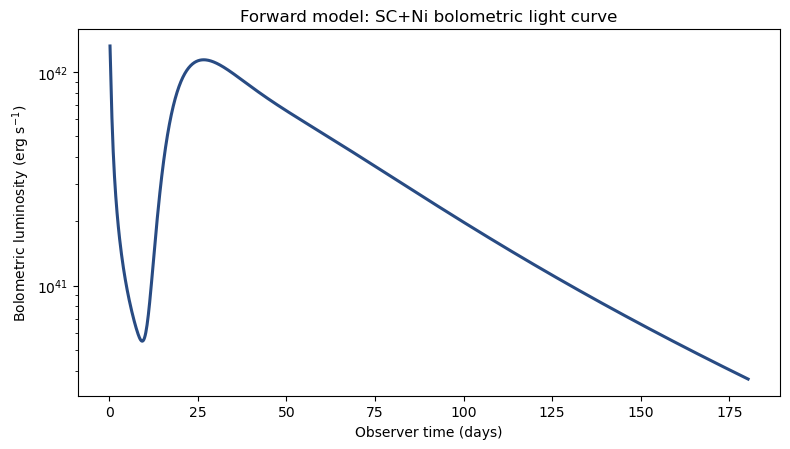

In [6]:
# Bolometric forward example (sc_ni)
theta_scni = (3.0, 1.0, 1.5, 0.08, 120.0, 0.2, 0.12, 0.03, 4500.0)
bol = tf.lightcurve_bol(
    model="sc_ni",
    theta=theta_scni,
    ctx=ctx_bol,
    t_max_days=180.0,
)

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.set_facecolor("white")
ax.plot(bol.t_days, bol.Lbol, color="#284b83", linewidth=2.2)


ax.set_yscale("log")
ax.set_xlabel("Observer time (days)")
ax.set_ylabel("Bolometric luminosity (erg s$^{-1}$)")
ax.set_title("Forward model: SC+Ni bolometric light curve")

plt.tight_layout()
plt.show()


Initializing and JIT-compiling the model...
Model is ready for fast execution.


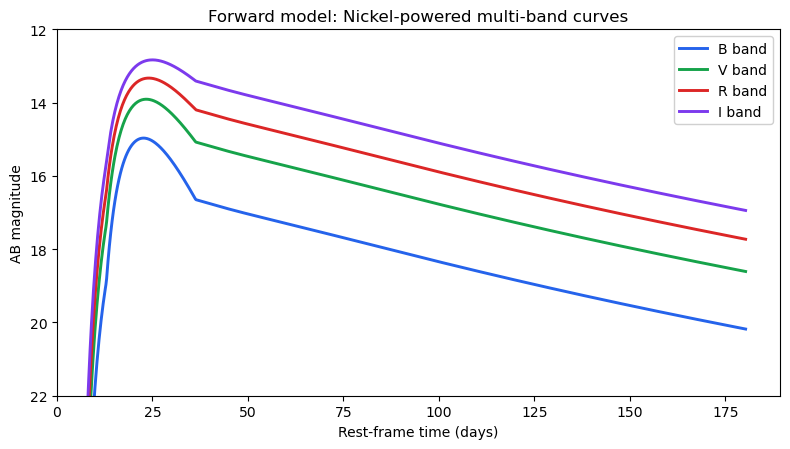

In [7]:
# Multi-band forward example (nickel)
theta_ni = (3.0, 1.0, 0.08, 0.2, 0.12, 0.03, 3000)
mb = tf.lightcurve_multiband(
    model="nickel",
    theta=theta_ni,
    ctx=ctx_mb,
    bands=["B", "V", "R", "I"],
    t_max_days=180.0,
)

palette = {
    "B": "#2563eb",
    "V": "#16a34a",
    "R": "#dc2626",
    "I": "#7c3aed",
}

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.set_facecolor("white")
for b in mb.bands:
    ax.plot(mb.t_days, mb.y[b], label=f"{b} band", color=palette.get(b, None), linewidth=2.1)

ax.set_xlim(left=0)
ax.set_ylim(12,22)
ax.set_xlabel("Rest-frame time (days)")
ax.set_ylabel("AB magnitude")
ax.invert_yaxis()  # brighter is lower magnitude
ax.set_title("Forward model: Nickel-powered multi-band curves")

leg = ax.legend(loc="upper right", frameon=True)
leg.get_frame().set_alpha(0.92)

plt.tight_layout()
plt.show()


## 4. Prepare Bolometric Data and Fit

`fit_bol` inputs:
- `data`: `tf.BolometricData`
- `model`: model key
- `ctx`: context
- `priors`: linear and/or log priors
- `fixed`: fixed parameter values
- `sampler`: `emcee`, `zeus`, or `dynesty`
- `sampler_kwargs`: backend settings
- `include_t_shift`: whether to fit `t_shift`

Grid-discretization parameters are handled internally in the default workflow and are not treated as standard user-facing fit parameters.


In [8]:
# Load example bolometric data
arr = np.loadtxt(DATA_DIR / "sn1993j_lbol.txt")

t_days = arr[:, 0] - np.min(arr[:, 0])
Lbol = arr[:, 1]
Lbol_err = arr[:, 2]

data_bol = tf.BolometricData(t_days=t_days, y=Lbol, yerr=Lbol_err)
print("Bolometric data size:", data_bol.t_days.size)


Bolometric data size: 89


In [9]:
# Quick demo fit (small chain for tutorial speed)
res_bol = tf.fit_bol(
    data=data_bol,
    model="sc_ni",
    ctx=ctx_bol,
    priors={
        "M_ej": (0.7, 5),
        "v_ej": (0.2, 3.0),
        "E_Th_in": (1.0, 10),
        "x_Ni":(0.1,0.9),
        "M_Ni": (0.01,0.2),
        "R_0": (100, 1200),
        "t_shift":(-5,5)
    },
    fixed={
        "kappa": 0.06,
        "kappa_gamma": 0.03,
    },
    sampler="emcee",
    sampler_kwargs=dict(
        nwalkers=32,
        nsteps=5000,
        burnin=300,
        thin=5,
        seed=520,
        progress=True,
    ),
    include_t_shift=True,
)


100%|██████████| 5000/5000 [02:38<00:00, 31.49it/s]


## 5. Understand `res` (`FitResult`)

Important fields:
- `res.param_names`: sampled/free parameters
- `res.all_param_names`: full parameter order
- `res.fixed`: fixed values used in fit
- `res.samples`: posterior samples `(Ns, ndim)`
- `res.log_prob`: log posterior values
- `res.meta`: metadata (bounds, priors, solver config, etc.)

Convenience accessors:
- `res.best_fit`, `res.best_fit_params`, `res.best_log_prob`
- `res.median_params`


In [10]:
print("model:", res_bol.model)
print("sampler:", res_bol.sampler)
print("param_names:", res_bol.param_names)
print("all_param_names:", res_bol.all_param_names)
print("samples shape:", res_bol.samples.shape)
print("best index:", res_bol.best_index)
print("best log_prob:", res_bol.best_log_prob)




model: sc_ni
sampler: emcee
param_names: ['M_ej', 'v_ej', 'E_Th_in', 'M_Ni', 'R_0', 'x_Ni', 't_shift']
all_param_names: ['M_ej', 'v_ej', 'E_Th_in', 'M_Ni', 'R_0', 'x_Ni', 'kappa', 'kappa_gamma', 't_shift']
samples shape: (32000, 7)
best index: 29888
best log_prob: -3718.7141858294744


In [11]:
res_bol.best_fit

{'index': 29888,
 'log_prob': -3718.7141858294744,
 'params': {'M_ej': 3.019,
  'v_ej': 0.9,
  'E_Th_in': 1.39,
  'M_Ni': 0.091,
  'R_0': 1198.797,
  'x_Ni': 0.442,
  'kappa': 0.06,
  'kappa_gamma': 0.03,
  't_shift': 0.151},
 'errors': {'M_ej': {'minus': 0.061,
   'plus': 0.051,
   'q16': 3.019,
   'q50': 3.08,
   'q84': 3.132,
   'fixed': False},
  'v_ej': {'minus': 0.009,
   'plus': 0.009,
   'q16': 0.902,
   'q50': 0.911,
   'q84': 0.92,
   'fixed': False},
  'E_Th_in': {'minus': 0.014,
   'plus': 0.407,
   'q16': 1.4,
   'q50': 1.414,
   'q84': 1.821,
   'fixed': False},
  'M_Ni': {'minus': 0.002,
   'plus': 0.002,
   'q16': 0.092,
   'q50': 0.093,
   'q84': 0.095,
   'fixed': False},
  'R_0': {'minus': 310.542,
   'plus': 3.146,
   'q16': 885.406,
   'q50': 1195.948,
   'q84': 1199.094,
   'fixed': False},
  'x_Ni': {'minus': 0.007,
   'plus': 0.017,
   'q16': 0.45,
   'q50': 0.457,
   'q84': 0.474,
   'fixed': False},
  'kappa': {'minus': 0.0,
   'plus': 0.0,
   'q16': 0.06,
   

## 6. Plot Bolometric Fit and Corner (Conner)

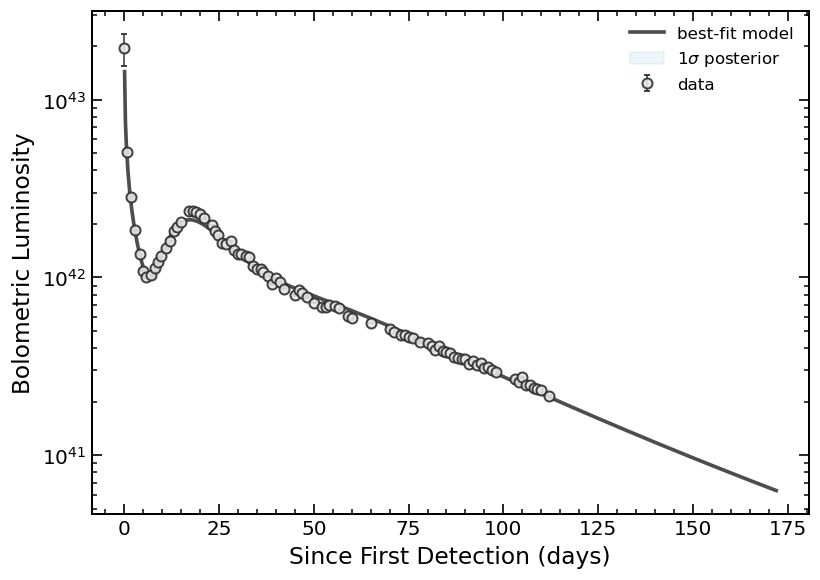

In [12]:
fig = tf.plot.fit_bol(
    res_bol,
    data=data_bol,
    show_1sigma=True,
    n_draws=200,
    t_pad=60.0,
)
fig


In [13]:
# Corner (Conner) plot for bolometric posterior
try:
    fig_corner_bol = tf.plot.corner(res_bol, max_points=10000)
    fig_corner_bol
except ImportError as e:
    print(e)
    print("Install with: pip install corner")


## 7. Prepare Multi-band Data and Fit

Expected `MultiBandData` format:
- `t_days`: observation times
- `band`: band labels (case-sensitive matching with `ctx.filters` keys)
- `y`: magnitude or flux values
- `yerr`: uncertainties


In [14]:
# Load and reshape example multi-band data (wide -> long)
df = pd.read_csv(DATA_DIR / "sn2007gr.csv")

t0 = float(np.nanmin(df["JD"].to_numpy(float)))
df["t_days"] = df["JD"].to_numpy(float) - t0

band_map = [
    ("B", "Bmag", "e_Bmag"),
    ("V", "Vmag", "e_Vmag"),
    ("R", "Rmag", "e_Rmag"),
    ("I", "Imag", "e_Imag"),
]

rows = []
for band, mag_col, err_col in band_map:
    if mag_col not in df.columns or err_col not in df.columns:
        continue

    y = pd.to_numeric(df[mag_col], errors="coerce").to_numpy(float)
    yerr = pd.to_numeric(df[err_col], errors="coerce").to_numpy(float)
    t = df["t_days"].to_numpy(float)

    mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    if not np.any(mask):
        continue

    rows.append(
        pd.DataFrame(
            {
                "t_days": t[mask],
                "band": np.full(np.sum(mask), band, dtype=object),
                "y": y[mask],
                "yerr": yerr[mask],
            }
        )
    )

lc = pd.concat(rows, ignore_index=True).sort_values("t_days").reset_index(drop=True)
# Optional cut for tutorial speed
lc = lc[lc["t_days"] < 110].reset_index(drop=True)

data_mb = tf.MultiBandData(
    t_days=lc["t_days"].to_numpy(float),
    band=lc["band"].to_numpy(dtype=object),
    y=lc["y"].to_numpy(float),
    yerr=lc["yerr"].to_numpy(float),
)

print("Multiband data size:", data_mb.t_days.size)
lc.head()


Multiband data size: 248


,t_days,band,y,yerr
0,0.00,B,13.987,0.023
1,0.00,I,13.430,0.024
2,0.00,R,13.519,0.024
3,0.00,V,13.695,0.024
4,0.13,B,13.821,0.057


In [15]:
# Multi-band fit example with emcee
res_mb = tf.fit_multiband(
    data=data_mb,
    model="ni",
    ctx=ctx_mb,
    priors={
        "M_ej": (1, 5),
        "v_ej": (0.3, 3.0),
        "M_Ni": (0.01, 0.5),
        "T_floor": (3000, 8000),
    },
    fixed={"kappa": 0.06},
    sampler="emcee",
    sampler_kwargs=dict(
        nwalkers=36,
        nsteps=3000,
        burnin=100,
        thin=5,
        seed=123,
        progress=True,
    ),
    include_t_shift=True,
)





Initializing and JIT-compiling the model...
Model is ready for fast execution.


100%|██████████| 3000/3000 [02:15<00:00, 22.11it/s]


In [16]:
print("model:", res_mb.model)
print("sampler:", res_mb.sampler)
print("param_names:", res_mb.param_names)
print("samples shape:", res_mb.samples.shape)

res_mb.best_fit


model: ni
sampler: emcee
param_names: ['M_ej', 'v_ej', 'M_Ni', 'x_Ni', 'kappa_gamma', 'T_floor', 't_shift']
samples shape: (21600, 7)


{'index': 18681,
 'log_prob': -3860.417614173097,
 'params': {'M_ej': 2.352,
  'v_ej': 0.615,
  'M_Ni': 0.063,
  'x_Ni': 0.81,
  'kappa': 0.06,
  'kappa_gamma': 0.023,
  'T_floor': 3824.567,
  't_shift': 7.959},
 'errors': {'M_ej': {'minus': 0.043,
   'plus': 0.053,
   'q16': 2.319,
   'q50': 2.363,
   'q84': 2.416,
   'fixed': False},
  'v_ej': {'minus': 0.008,
   'plus': 0.011,
   'q16': 0.608,
   'q50': 0.616,
   'q84': 0.627,
   'fixed': False},
  'M_Ni': {'minus': 0.001,
   'plus': 0.001,
   'q16': 0.061,
   'q50': 0.062,
   'q84': 0.063,
   'fixed': False},
  'x_Ni': {'minus': 0.015,
   'plus': 0.014,
   'q16': 0.792,
   'q50': 0.806,
   'q84': 0.82,
   'fixed': False},
  'kappa': {'minus': 0.0,
   'plus': 0.0,
   'q16': 0.06,
   'q50': 0.06,
   'q84': 0.06,
   'fixed': True},
  'kappa_gamma': {'minus': 0.0,
   'plus': 0.001,
   'q16': 0.022,
   'q50': 0.023,
   'q84': 0.023,
   'fixed': False},
  'T_floor': {'minus': 4.912,
   'plus': 5.036,
   'q16': 3819.241,
   'q50': 3824.15

## 8. Plot Multi-band Fit and Corner (Conner)

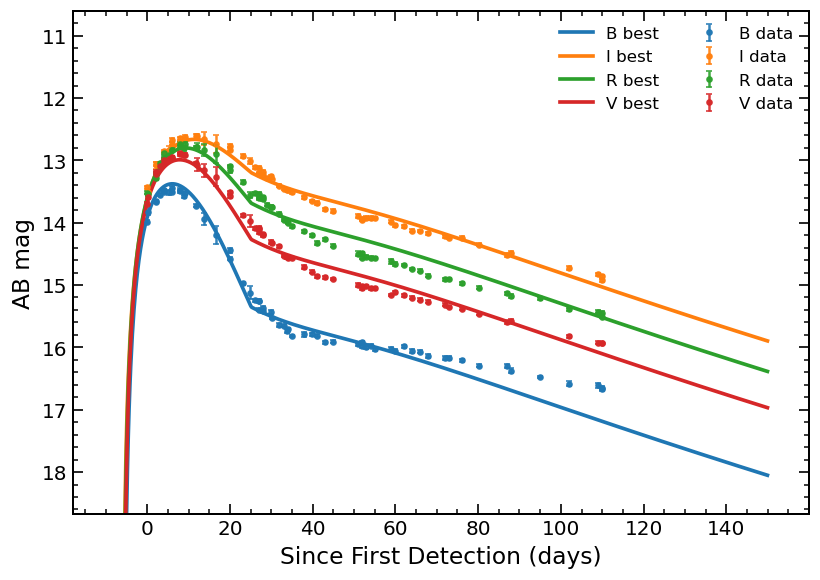

In [17]:
fig_mb = tf.plot.fit_multiband(
    res_mb,
    data=data_mb,
    show_1sigma=True,
    n_draws=200,
    t_pad=40.0,
)
fig_mb


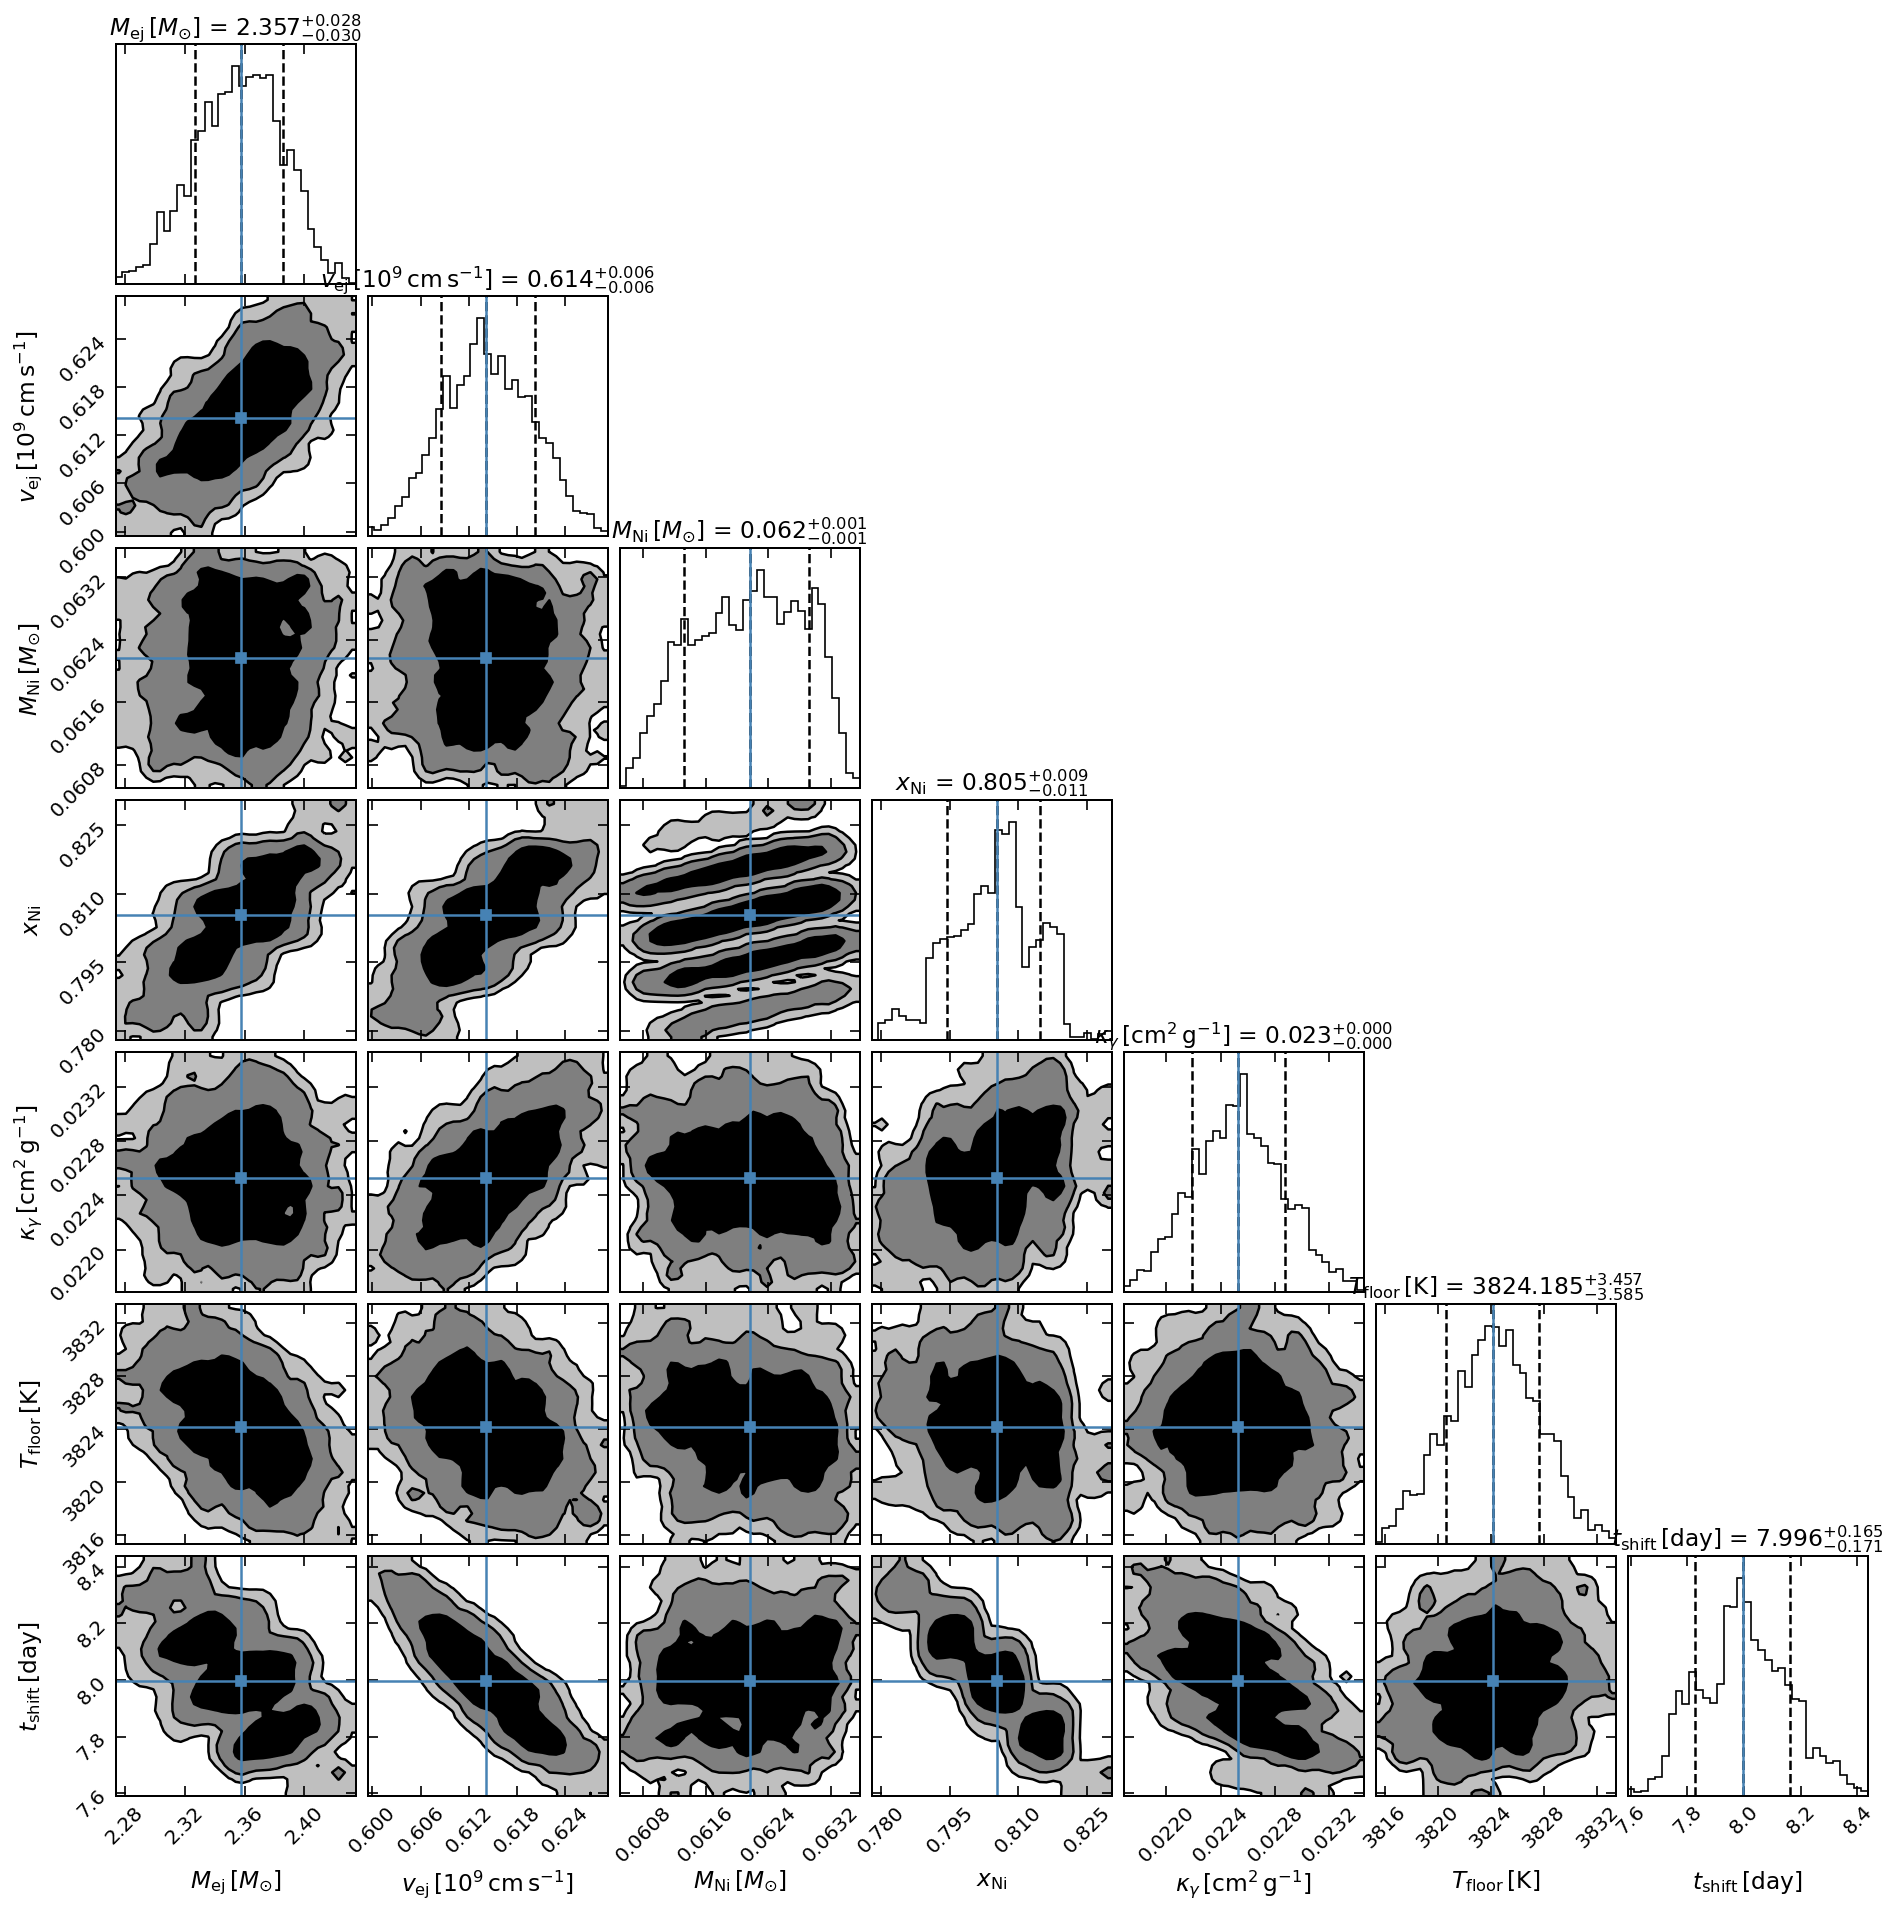

In [18]:
# Corner (Conner) plot for multi-band posterior
tf.plot.corner(res_mb, max_points=10000)


## 9. Custom Plotting (Minimal)

If you do not want to use `tf.plot.*`, the minimal workflow is:
1. Read best-fit model input directly: `theta_best = res.best_theta` (and `t_shift_best = res.best_t_shift` if needed).
2. Call `tf.predict_bol(...)` or `tf.predict_multiband(...)` to compute theoretical curves.
3. Plot model + observed data with your own matplotlib style.


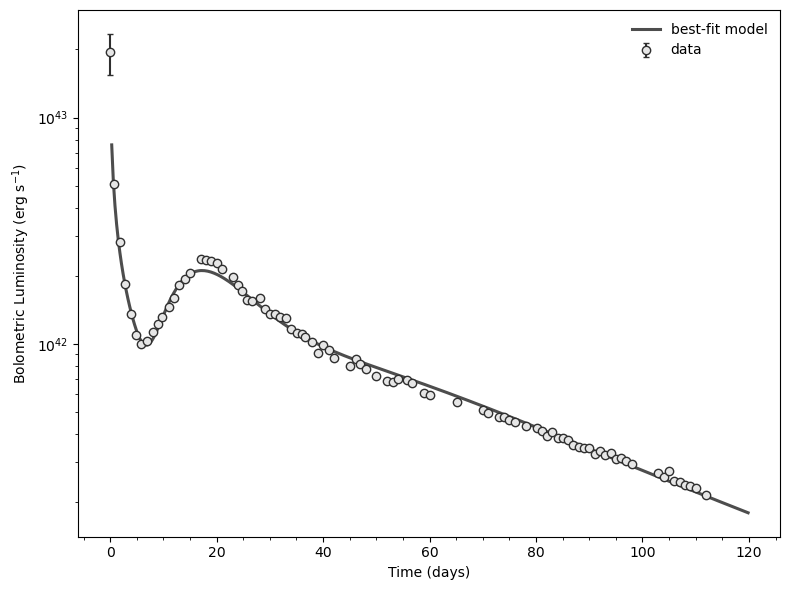

In [32]:
# Step 1: read best-fit model input directly
theta_best = res_bol.best_theta
t_shift_best = res_bol.best_t_shift

# Step 2: compute theoretical curve on a custom time grid
t_line = np.linspace(-2.0, 120.0, 400)
L_line = tf.predict_bol(
    model=res_bol.model,
    theta=theta_best,
    ctx=ctx_bol,
    t_days=t_line ,
    interp_fill="nan",
)

# Step 3: plot data + model and tune style
fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    data_bol.t_days, data_bol.y, yerr=data_bol.yerr,
    fmt="o", ms=6, mfc="#E6E6E6", mec="#2F2F2F", ecolor="#2F2F2F",
    capsize=2, label="data"
)
ax.plot(t_line-t_shift_best, L_line, color="#4D4D4D", lw=2.2, label="best-fit model")
ax.set_yscale("log")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Bolometric Luminosity (erg s$^{-1}$)")
ax.legend(frameon=False)
ax.minorticks_on()
fig.tight_layout()


### Multi-band Minimal Example

Use the same 3-step flow for multi-band data: read best-fit parameters, compute model curves, then style the figure.


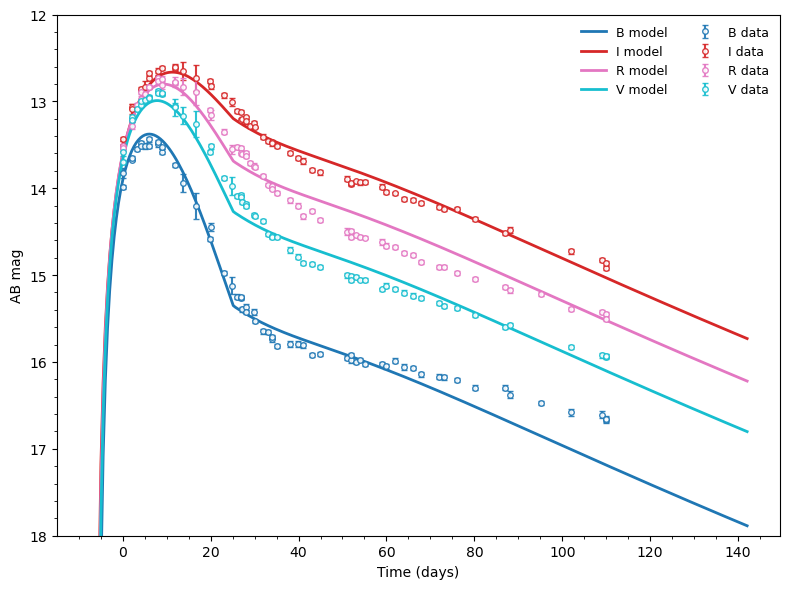

In [31]:
# Step 1: read best-fit model input directly
theta_mb = res_mb.best_theta
t_shift_mb = res_mb.best_t_shift

# Step 2: compute model curves for each band
bands = list(dict.fromkeys(data_mb.band.tolist()))
t_line = np.linspace(0,150 , 300)
colors = dict(zip(bands, plt.cm.tab10(np.linspace(0, 1, len(bands)))))

fig, ax = plt.subplots(figsize=(8, 6))
for b in bands:
    m = (data_mb.band == b)
    y_line = tf.predict_multiband(
        model=res_mb.model,
        theta=theta_mb,
        ctx=ctx_mb,
        t_days=t_line,
        band=np.array([b] * len(t_line), dtype=object),
        interp_fill="nan",
    )
    ax.errorbar(
        data_mb.t_days[m], data_mb.y[m], yerr=data_mb.yerr[m],
        fmt="o", ms=4, mfc="white", mec=colors[b], ecolor=colors[b],
        capsize=2, alpha=0.9, label=f"{b} data"
    )
    ax.plot(t_line-t_shift_mb, y_line, color=colors[b], lw=2.0, label=f"{b} model")

# Step 3: optimize figure style
ax.set_xlabel("Time (days)")
ax.set_ylabel("AB mag")
ax.set_ylim(18, 12)
ax.legend(ncol=2, frameon=False, fontsize=9)
ax.minorticks_on()
fig.tight_layout()


## 10. Save and Load


In [21]:
out_path = tf.save(res_mb, path=Path("mcmc_out") / "fit_magnetar_ni_demo.npz")
loaded = tf.load(out_path)

print("saved to:", out_path)
print("loaded model:", loaded["model"])
print("loaded sampler:", loaded["sampler"])
print("loaded samples shape:", loaded["samples"].shape)


saved to: /Users/zyh/Desktop/Transfit_v0.4/examples/mcmc_out/fit_magnetar_ni_demo.npz
loaded model: ni
loaded sampler: emcee
loaded samples shape: (21600, 7)
